In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/faceforensics/FF++/fake/02_13__exit_phone_room__CP5HFV3K.mp4
/kaggle/input/faceforensics/FF++/fake/03_14__talking_against_wall__ZC2KYASW.mp4
/kaggle/input/faceforensics/FF++/fake/03_15__outside_talking_pan_laughing__Y11NT1YX.mp4
/kaggle/input/faceforensics/FF++/fake/07_26__walking_down_street_outside_angry__FGNGC2GT.mp4
/kaggle/input/faceforensics/FF++/fake/07_03__hugging_happy__7NGMD8FT.mp4
/kaggle/input/faceforensics/FF++/fake/07_09__walk_down_hall_angry__N9CWME71.mp4
/kaggle/input/faceforensics/FF++/fake/01_12__outside_talking_pan_laughing__TNI7KUZ6.mp4
/kaggle/input/faceforensics/FF++/fake/07_03__podium_speech_happy__6PHZRQ4H.mp4
/kaggle/input/faceforensics/FF++/fake/07_02__walking_down_street_outside_angry__O4SXNLRL.mp4
/kaggle/input/faceforensics/FF++/fake/08_05__walk_down_hall_angry__FBICSP2C.mp4
/kaggle/input/faceforensics/FF++/fake/06_18__outside_talking_pan_laughing__DEA1TCLN.mp4
/kaggle/input/faceforensics/FF++/fake/01_03__talking_against_wall__JZUXXFRB.mp4
/ka

In [5]:
import os
import cv2
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Dataset paths
REAL_PATH = "/kaggle/input/faceforensics/FF++/real"
FAKE_PATH = "/kaggle/input/faceforensics/FF++/fake"
OUTPUT_FRAME_SIZE = (128, 128)  # Frame dimensions
FRAME_COUNT = 10  # Number of frames to extract per video
MAX_VIDEOS = 700  # Number of videos to process from each category

In [6]:
# Function to extract frames from a video
def extract_frames(video_path, output_size=(128, 128), frame_count=10):
    cap = cv2.VideoCapture(video_path)
    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step = max(total_frames // frame_count, 1)  # Uniform sampling
    
    for i in range(frame_count):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * step)
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.resize(frame, output_size)
        frames.append(frame)
    cap.release()
    return np.array(frames)

# Prepare data and labels
data = []
labels = []

# Process real videos
print("Processing real videos...")
real_videos = os.listdir(REAL_PATH)[:MAX_VIDEOS]   # Limit to 300 videos
for video_file in tqdm(real_videos):
    video_path = os.path.join(REAL_PATH, video_file)
    frames = extract_frames(video_path, output_size=OUTPUT_FRAME_SIZE, frame_count=FRAME_COUNT)
    if len(frames) == FRAME_COUNT:  # Ensure correct frame count
        data.append(frames)
        labels.append(0)  # Label 0 for real

Processing real videos...


100%|██████████| 200/200 [12:12<00:00,  3.66s/it]


In [7]:
%%time
# Process fake videos
print("Processing fake videos...")
fake_videos = os.listdir(FAKE_PATH)[:MAX_VIDEOS]  # Limit to 300 videos
for video_file in tqdm(fake_videos):
    video_path = os.path.join(FAKE_PATH, video_file)
    frames = extract_frames(video_path, output_size=OUTPUT_FRAME_SIZE, frame_count=FRAME_COUNT)
    if len(frames) == FRAME_COUNT:
        data.append(frames)
        labels.append(1)  # Label 1 for fake

# Convert to numpy arrays
data = np.array(data)  # Shape: (num_videos, num_frames, 128, 128, 3)
labels = np.array(labels)

# Split into train, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(data, labels, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Normalize data
X_train = X_train / 255.0
X_val = X_val / 255.0
X_test = X_test / 255.0

# Convert labels to categorical
y_train = to_categorical(y_train, num_classes=2)
y_val = to_categorical(y_val, num_classes=2)
y_test = to_categorical(y_test, num_classes=2)

print(f"Data shapes: Train - {X_train.shape}, Validation - {X_val.shape}, Test - {X_test.shape}")


Processing fake videos...


100%|██████████| 200/200 [12:02<00:00,  3.61s/it]


Data shapes: Train - (280, 10, 128, 128, 3), Validation - (60, 10, 128, 128, 3), Test - (60, 10, 128, 128, 3)
CPU times: user 39min 5s, sys: 1min, total: 40min 5s
Wall time: 12min 3s


In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Augment frames
datagen = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.1,
    brightness_range=[0.8, 1.2]
)

# Function to augment extracted frames
def augment_frames(frames):
    augmented_frames = []
    for frame in frames:
        frame = datagen.random_transform(frame)
        augmented_frames.append(frame)
    return np.array(augmented_frames)

# Augment training data
augmented_data = []
augmented_labels = []

for i in range(len(X_train)):
    augmented_frames = augment_frames(X_train[i])
    augmented_data.append(augmented_frames)
    augmented_labels.append(y_train[i])

# Combine original and augmented data
X_train_augmented = np.concatenate((X_train, np.array(augmented_data)))
y_train_augmented = np.concatenate((y_train, np.array(augmented_labels)))

print(f"Augmented Train Data: {X_train_augmented.shape}")


Augmented Train Data: (560, 10, 128, 128, 3)


In [9]:
import tensorflow as tf
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import Dense, Flatten, TimeDistributed, LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout

# Define model
def build_improved_model(input_shape=(FRAME_COUNT, 128, 128, 3)):
    model = Sequential([
        TimeDistributed(Xception(weights='imagenet', include_top=False, input_shape=(128, 128, 3))),
        TimeDistributed(Flatten()),
        Dropout(0.5),  # Add dropout for regularization
        LSTM(128, return_sequences=False),
        Dropout(0.5),  # Add dropout
        Dense(64, activation='relu'),
        Dense(2, activation='softmax')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model = build_improved_model()
model.summary()

I0000 00:00:1745075784.892691      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ time_distributed (TimeDistributed)   │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_1 (TimeDistributed) │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 20,861,480 (79.58 MB)

 Trainable params: 20,806,952 (79.37 MB)

 Non-trainable params: 54,528 (213.00 KB)

In [11]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

# Model checkpoint to save the best model in .keras format
checkpoint = ModelCheckpoint(
    "A19.keras",  # Change to .keras
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

# Reduce learning rate on plateau
lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    verbose=1
)

# Train the model
history = model.fit(
    X_train_augmented, y_train_augmented,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=10,
    callbacks=[checkpoint, lr_scheduler]
)
model.save("A20.keras")

Epoch 1/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 573ms/step - accuracy: 0.6903 - loss: 0.4764
Epoch 1: val_accuracy improved from -inf to 0.66667, saving model to A19.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 36s 640ms/step - accuracy: 0.6903 - loss: 0.4765 - val_accuracy: 0.6667 - val_loss: 1.3214 - learning_rate: 7.8125e-07
Epoch 2/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 572ms/step - accuracy: 0.7009 - loss: 0.4785
Epoch 2: val_accuracy did not improve from 0.66667
56/56 ━━━━━━━━━━━━━━━━━━━━ 33s 587ms/step - accuracy: 0.7005 - loss: 0.4788 - val_accuracy: 0.6333 - val_loss: 1.3397 - learning_rate: 7.8125e-07
Epoch 3/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 572ms/step - accuracy: 0.6861 - loss: 0.4950
Epoch 3: val_accuracy did not improve from 0.66667
56/56 ━━━━━━━━━━━━━━━━━━━━ 33s 587ms/step - accuracy: 0.6859 - loss: 0.4952 - val_accuracy: 0.6500 - val_loss: 1.3179 - learning_rate: 7.8125e-07
Epoch 4/40
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 573ms/step - accuracy: 0.7048 - loss: 0.4807
Epoch 4: val_accuracy did not improve

**Model Testing**

In [12]:
from sklearn.metrics import classification_report, accuracy_score

# Load the best saved model
from tensorflow.keras.models import load_model
model = load_model('A20.keras')

# Evaluate on test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Metrics
accuracy = accuracy_score(y_true, y_pred_classes)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Precision, Recall, F1-Score
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=['REAL', 'FAKE']))

2/2 ━━━━━━━━━━━━━━━━━━━━ 28s 14s/step
Test Accuracy: 61.67%
Classification Report:
              precision    recall  f1-score   support

        REAL       0.71      0.52      0.60        33
        FAKE       0.56      0.74      0.63        27

    accuracy                           0.62        60
   macro avg       0.63      0.63      0.62        60
weighted avg       0.64      0.62      0.61        60



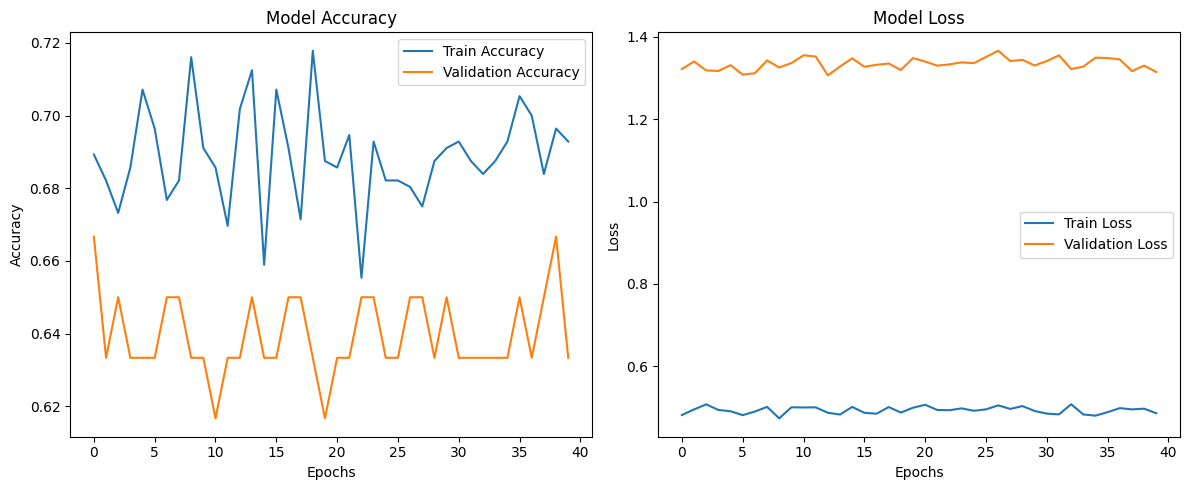

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 259ms/step


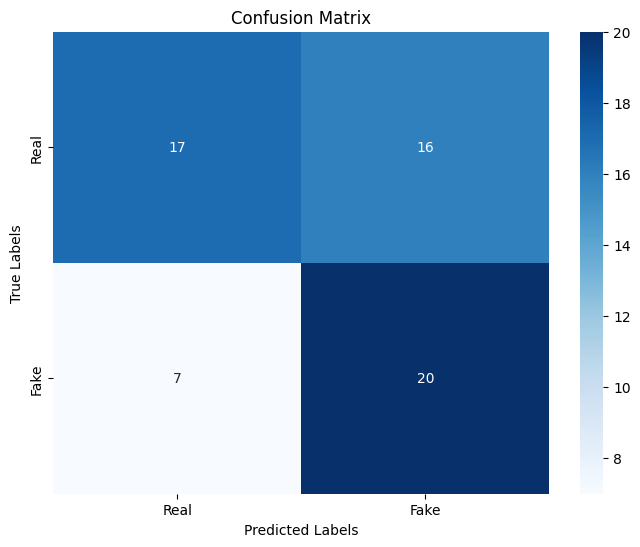

              precision    recall  f1-score   support

        Real       0.71      0.52      0.60        33
        Fake       0.56      0.74      0.63        27

    accuracy                           0.62        60
   macro avg       0.63      0.63      0.62        60
weighted avg       0.64      0.62      0.61        60



In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# Plot accuracy and loss graphs
def plot_training_history(history):
    # Accuracy
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Compute confusion matrix
def plot_confusion_matrix(model, X_test, y_test):
    # Get predictions
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = np.argmax(y_test, axis=1)

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred_classes)
    cm_labels = ['Real', 'Fake']

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cm_labels, yticklabels=cm_labels)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()

    # Classification report
    print(classification_report(y_true, y_pred_classes, target_names=cm_labels))

# Plot training history
plot_training_history(history)

# Plot confusion matrix
plot_confusion_matrix(model, X_test, y_test)


**Real Time Detection**

In [14]:
import os
import cv2
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [15]:
# Function to extract frames from a video
def extract_frames(video_path, output_size=(128, 128), frame_count=10):
    cap = cv2.VideoCapture(video_path)
    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step = max(total_frames // frame_count, 1)  # Uniform sampling

    for i in range(frame_count):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * step)
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.resize(frame, output_size)
        frames.append(frame)
    cap.release()
    return np.array(frames)

In [18]:
from tensorflow.keras.models import load_model

# Load the model for real-time detection
loaded_model = load_model('A19.keras')

def predict_video(video_path, model, output_size=(128, 128), frame_count=10):
    frames = extract_frames(video_path, output_size, frame_count)
    frames = frames / 255.0  # Normalize
    frames = np.expand_dims(frames, axis=0)  # Add batch dimension
    prediction = model.predict(frames)
    label = "FAKE" if np.argmax(prediction) == 1 else "REAL"
    confidence = prediction[0][np.argmax(prediction)]
    print(f"Prediction: {label} (Confidence: {confidence:.2f})")

REAL_PATH = "/kaggle/input/faceforensics/FF++/fake/02_09__exit_phone_room__HIH8YA82.mp4"
FAKE_PATH = "/kaggle/input/faceforensics/FF++/real/01__exit_phone_room.mp4"
# Test prediction on a video
real_sample_path = os.path.join(REAL_PATH, "/kaggle/input/faceforensics/FF++/real/01__talking_angry_couch.mp4")  # Replace with real video path
fake_sample_path = os.path.join(FAKE_PATH, "/kaggle/input/faceforensics/FF++/fake/02_06__talking_angry_couch__MKZTXQ2T.mp4")  # Replace with fake video path

print("Real Video Prediction:")
predict_video(real_sample_path,loaded_model)

print("Fake Video Prediction:")
predict_video(fake_sample_path,loaded_model)

Real Video Prediction:
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step
Prediction: REAL (Confidence: 1.00)
Fake Video Prediction:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Prediction: FAKE (Confidence: 0.99)


In [19]:
# Example: model is your trained Keras model
model.save('A19.h5')  # Save as HDF5 file/kaggle/working/A19.keras

In [ ]:
model.save('A19.keras')